# Lifestyle Model

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, joblib
warnings.filterwarnings("ignore") 

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# Exploratory Data Analysis (EDA) + Data Cleaning


## load and analyse dataset

In [4]:
df = pd.read_csv("lifestyle.csv")

In [5]:
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [6]:
df.shape

(253680, 22)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
Diabetes,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [9]:
target = "HeartDiseaseorAttack"
lifestyle_cols = ["Age","Sex","BMI","Smoker","HvyAlcoholConsump","PhysActivity","Fruits","Veggies","Diabetes"]
print(lifestyle_cols)

['Age', 'Sex', 'BMI', 'Smoker', 'HvyAlcoholConsump', 'PhysActivity', 'Fruits', 'Veggies', 'Diabetes']


In [10]:
# encoding
for c in ["Sex","Smoker","HvyAlcoholConsump","PhysActivity","Fruits","Veggies", target]:
    print(c, df[c].unique())

Sex [0. 1.]
Smoker [1. 0.]
HvyAlcoholConsump [0. 1.]
PhysActivity [0. 1.]
Fruits [0. 1.]
Veggies [1. 0.]
HeartDiseaseorAttack [0. 1.]


## missing values

In [11]:
df.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## duplicate values

In [12]:
df.duplicated().sum()

np.int64(23899)

## target distribution

In [13]:
df[target].value_counts(normalize=True) * 100

HeartDiseaseorAttack
0.0    90.581441
1.0     9.418559
Name: proportion, dtype: float64

<Axes: xlabel='HeartDiseaseorAttack'>

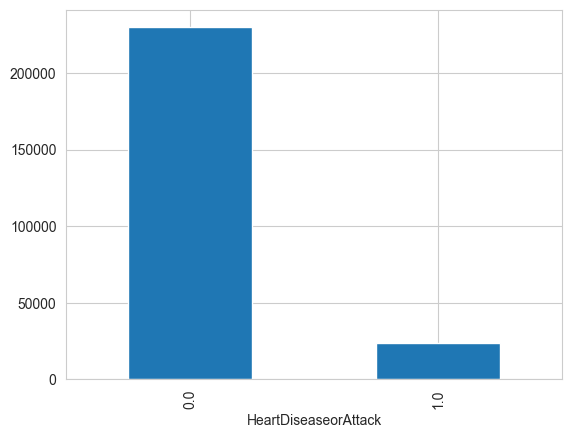

In [14]:
df[target].value_counts().plot(kind = 'bar')

# feature analysis

In [15]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

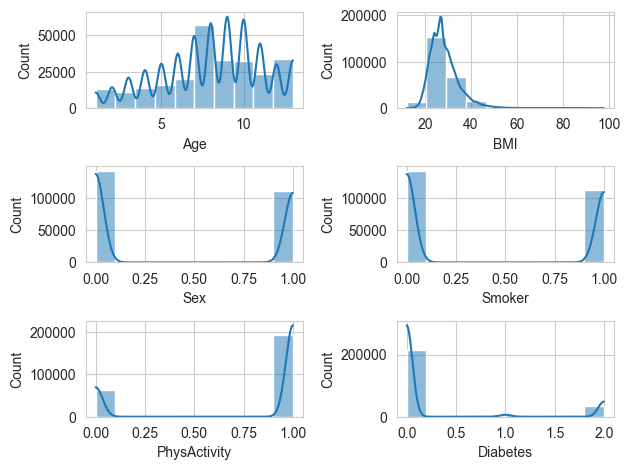

In [16]:
def plotting(var,num):
    plt.subplot(3,2,num)
    sns.histplot(df[var], bins=10, kde = True)

plotting('Age',1)
plotting('BMI',2)
plotting('Sex',3)
plotting('Smoker',4)
plotting('PhysActivity',5)
plotting('Diabetes',6)

plt.tight_layout()


In [17]:
# BMI Outliers
df["BMI"].describe()


count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64

<Axes: xlabel='BMI'>

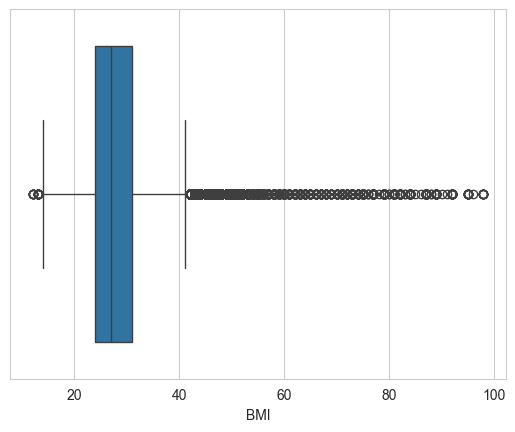

In [18]:
sns.boxplot(x=df["BMI"])

In [19]:
(df["BMI"] > 60).sum()

np.int64(805)

In [20]:
cat_cols = ["Age","Sex","Smoker","HvyAlcoholConsump","PhysActivity","Fruits","Veggies","Diabetes"]
for c in cat_cols:
    print(df[c].value_counts(normalize=True).round(3), "\n")

Age
9.0     0.131
10.0    0.127
8.0     0.122
7.0     0.104
11.0    0.093
6.0     0.078
13.0    0.068
5.0     0.064
12.0    0.063
4.0     0.054
3.0     0.044
2.0     0.030
1.0     0.022
Name: proportion, dtype: float64 

Sex
0.0    0.56
1.0    0.44
Name: proportion, dtype: float64 

Smoker
0.0    0.557
1.0    0.443
Name: proportion, dtype: float64 

HvyAlcoholConsump
0.0    0.944
1.0    0.056
Name: proportion, dtype: float64 

PhysActivity
1.0    0.757
0.0    0.243
Name: proportion, dtype: float64 

Fruits
1.0    0.634
0.0    0.366
Name: proportion, dtype: float64 

Veggies
1.0    0.811
0.0    0.189
Name: proportion, dtype: float64 

Diabetes
0.0    0.842
2.0    0.139
1.0    0.018
Name: proportion, dtype: float64 



In [21]:
# age is not an actual age here, its a category
df["Age"].value_counts().sort_index()

Age
1.0      5700
2.0      7598
3.0     11123
4.0     13823
5.0     16157
6.0     19819
7.0     26314
8.0     30832
9.0     33244
10.0    32194
11.0    23533
12.0    15980
13.0    17363
Name: count, dtype: int64

In [22]:
# for diabetes - 3 category
df["Diabetes"].value_counts().sort_index()

Diabetes
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

<Axes: title={'center': 'Heart disease rate by BMI category'}, xlabel='_BMI_cat_eda'>

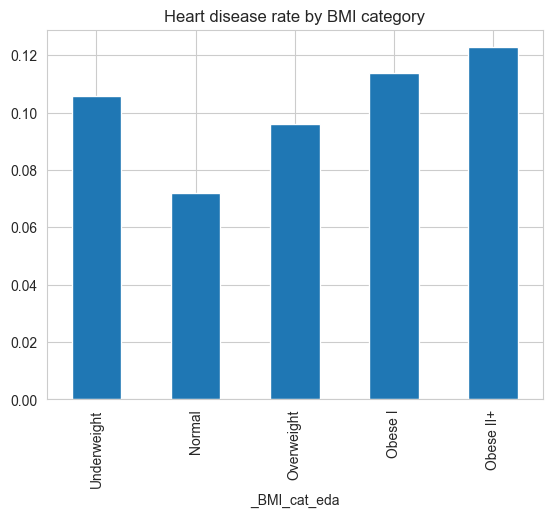

In [23]:
bins = [0, 18.5, 25, 30, 35, 100]
labels = ["Underweight", "Normal", "Overweight", "Obese I", "Obese II+"]
df["_BMI_cat_eda"] = pd.cut(df["BMI"], bins=bins, labels=labels)
rate = df.groupby("_BMI_cat_eda")[target].mean()
rate.plot(kind="bar", title="Heart disease rate by BMI category")


In [24]:
df.drop(columns="_BMI_cat_eda", inplace=True)

## feature vs target

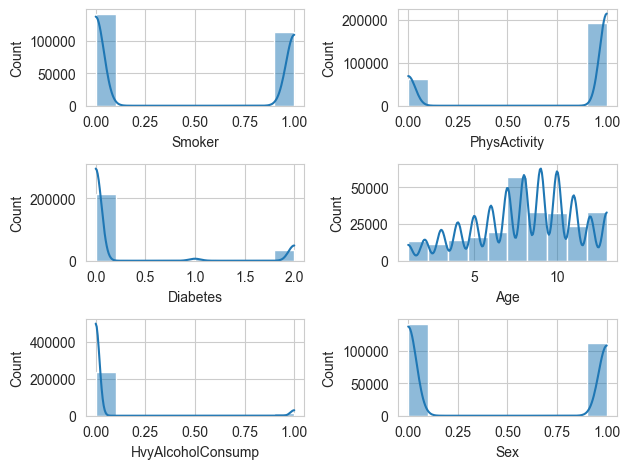

In [25]:
plotting('Smoker',1)
plotting('PhysActivity',2)
plotting('Diabetes',3)
plotting('Age',4)
plotting('HvyAlcoholConsump',5)
plotting('Sex',6)
plt.tight_layout()

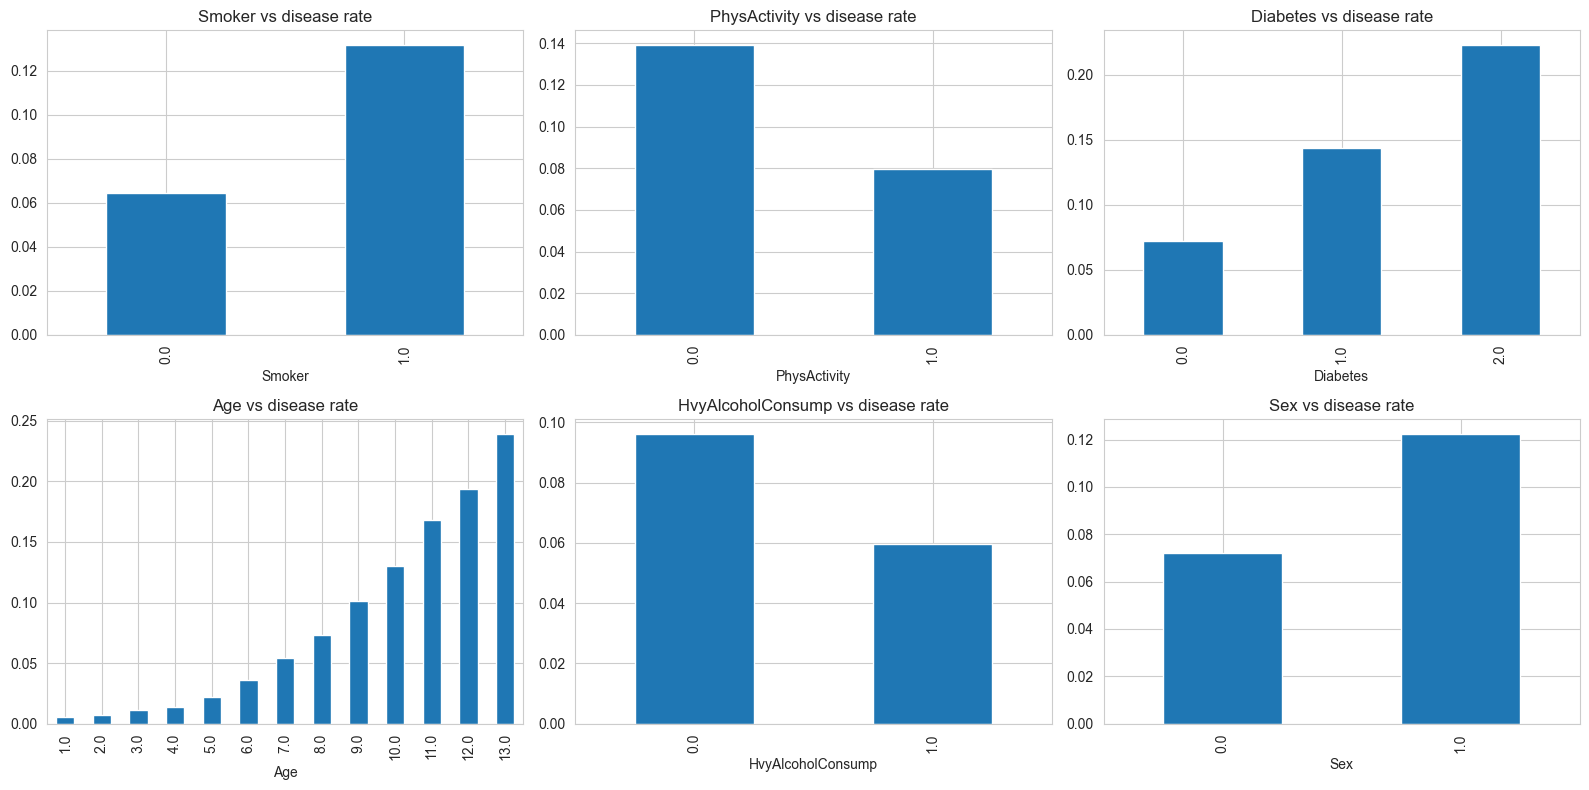

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, ["Smoker","PhysActivity","Diabetes","Age","HvyAlcoholConsump","Sex"]):
    rate = df.groupby(col)[target].mean()
    rate.plot(kind="bar", ax=ax, title=f"{col} vs disease rate")
plt.tight_layout()

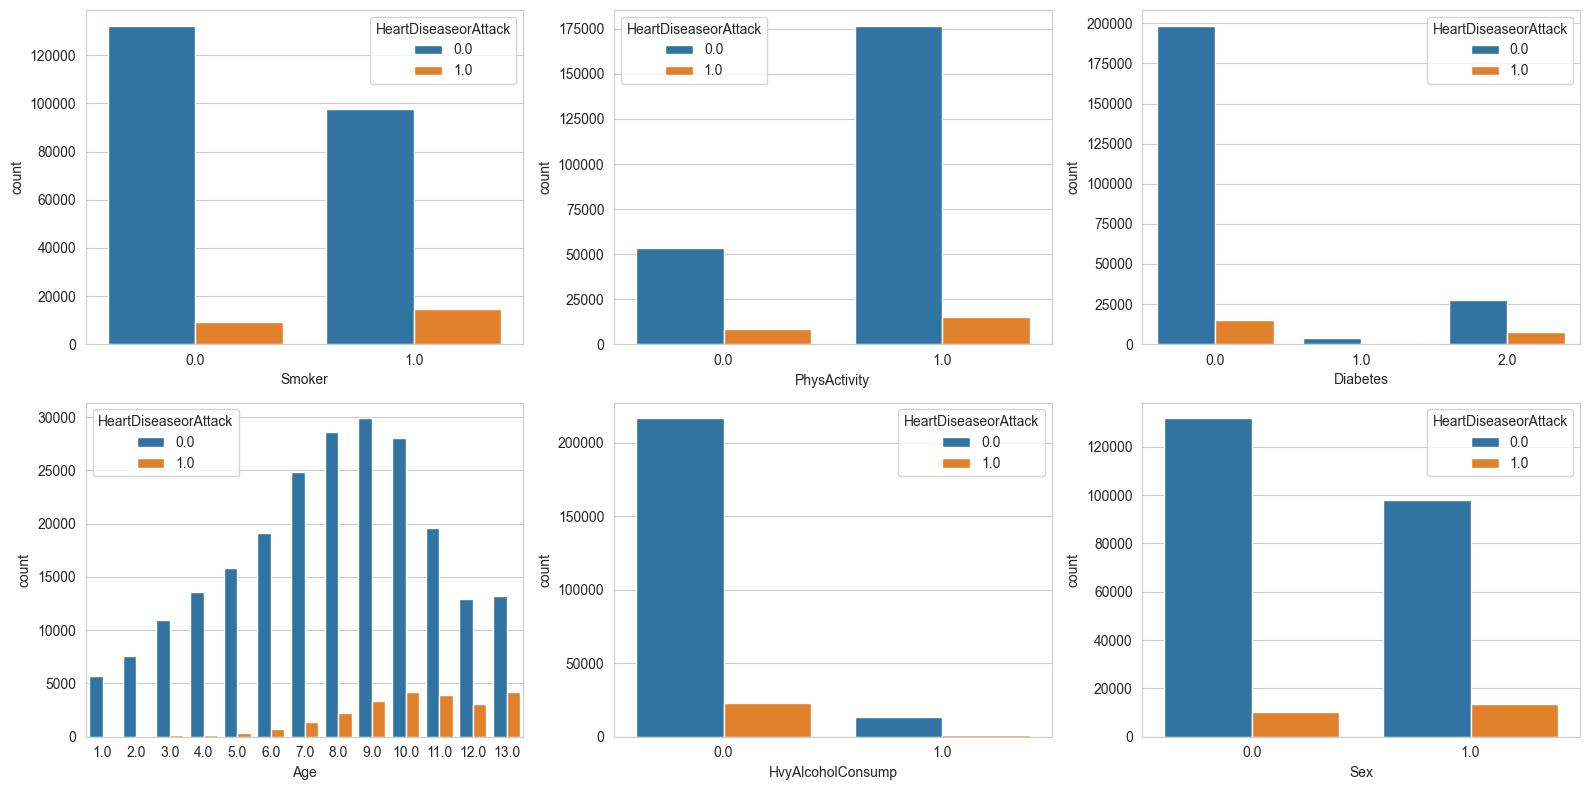

In [27]:
fig = plt.subplots(2, 3, figsize=(16, 8))
def count_plotting(val,num):
    plt.subplot(2,3,num)
    sns.countplot(x=df[val], hue = df[target])  

count_plotting('Smoker',1)
count_plotting('PhysActivity',2)
count_plotting('Diabetes',3)
count_plotting('Age',4)
count_plotting('HvyAlcoholConsump',5)
count_plotting('Sex',6)

plt.tight_layout()

<Axes: >

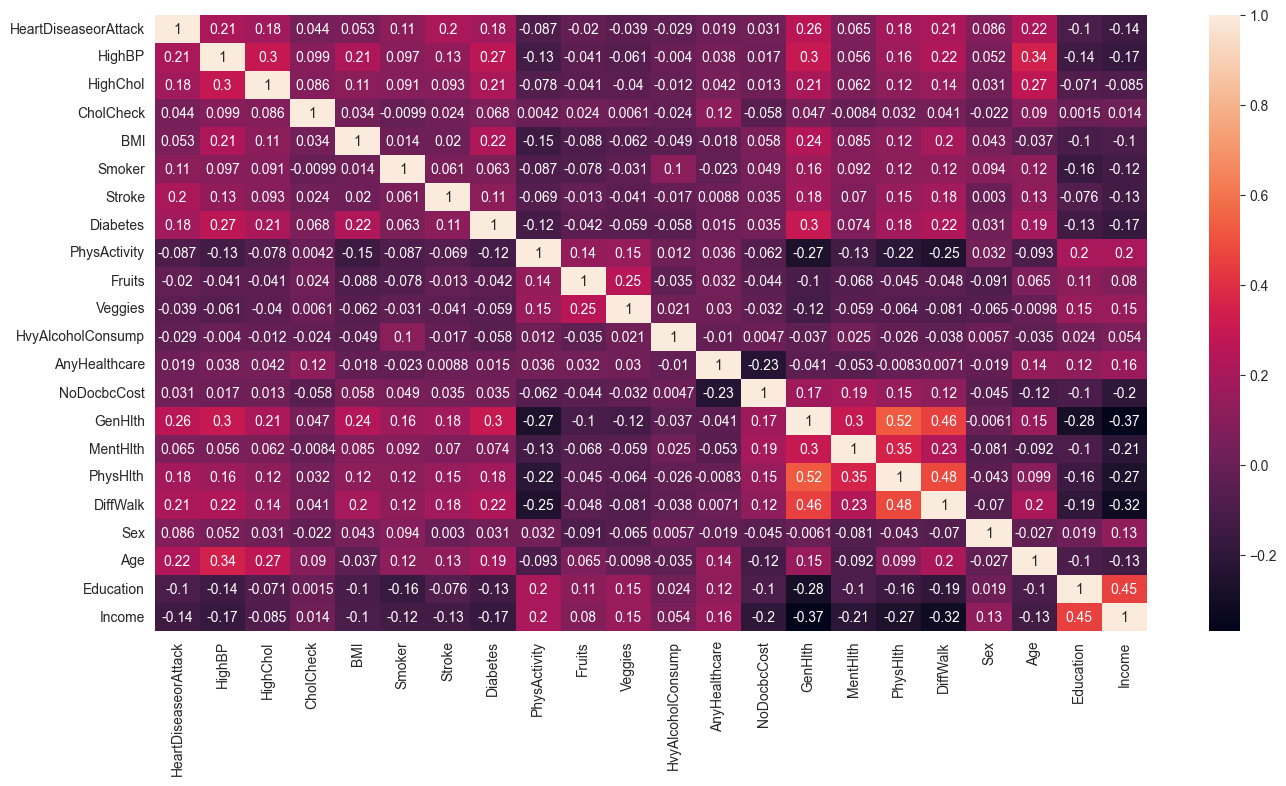

In [28]:
# HeatMap for correlation prediction
fig = plt.subplots(figsize=(16, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Feature Set
```
Age, Sex, BMI, Smoker, HvyAlcoholConsump, PhysActivity, Fruits, Veggies, Diabetes
```

Excluded: HighBP, HighChol, CholCheck, Stroke, GenHlth, MentHlth, PhysHlth, DiffWalk, AnyHealthcare, NoDocbcCost, Education, Income — reserved for a separate clinical-stage model.

# Data Preprocessing

In [29]:
df.shape

(253680, 22)

In [30]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

In [31]:
df_cleaned = df.drop_duplicates().reset_index(drop=True)
print("After dedup:", df_cleaned.shape)
print("Before dedup:", df.shape)


After dedup: (229781, 22)
Before dedup: (253680, 22)


In [32]:
X = df_cleaned[lifestyle_cols].copy()
y = df_cleaned[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(183824, 9) (45957, 9)
0.10321829576116286 0.10320517005026437


In [33]:
numeric_features = ["BMI"]
categorical_features = ["Age","Sex","Smoker","HvyAlcoholConsump","PhysActivity","Fruits","Veggies","Diabetes"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

## MODEL TRAINING

In [34]:
# Dummy baseline
dummy = Pipeline([("prep", preprocessor), ("clf", DummyClassifier(strategy="most_frequent"))])
dummy.fit(X_train, y_train)
pred = dummy.predict(X_test)
print("Dummy accuracy:", accuracy_score(y_test, pred))
print("Dummy recall:", recall_score(y_test, pred))

Dummy accuracy: 0.8967948299497356
Dummy recall: 0.0


In [35]:
# Logistic Regression
log_reg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))
])
log_reg.fit(X_train, y_train)
pred = log_reg.predict(X_test)
proba = log_reg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba), "| PR-AUC:", average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.96      0.67      0.79     41214
           1       0.21      0.74      0.32      4743

    accuracy                           0.68     45957
   macro avg       0.58      0.71      0.56     45957
weighted avg       0.88      0.68      0.74     45957

ROC-AUC: 0.774358027252601 | PR-AUC: 0.26255776748708815


In [36]:
# Random Forest
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1))
])
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba), "| PR-AUC:", average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83     41214
           1       0.20      0.53      0.29      4743

    accuracy                           0.73     45957
   macro avg       0.57      0.64      0.56     45957
weighted avg       0.86      0.73      0.78     45957

ROC-AUC: 0.6879335634912005 | PR-AUC: 0.20047659939848955


In [37]:
import sys
!{sys.executable} -m pip uninstall xgboost -y
!{sys.executable} -m pip install xgboost --no-cache-dir    

Found existing installation: xgboost 3.4.0
Uninstalling xgboost-3.4.0:
  Successfully uninstalled xgboost-3.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.9 MB/s  0:00:00


In [38]:
from xgboost import XGBClassifier 

In [39]:
# Gradient Boosting (XGBoost)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8,
                           scale_pos_weight=scale_pos_weight,
                           eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))
])
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
proba = xgb.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba), "| PR-AUC:", average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.96      0.65      0.78     41214
           1       0.20      0.76      0.32      4743

    accuracy                           0.67     45957
   macro avg       0.58      0.71      0.55     45957
weighted avg       0.88      0.67      0.73     45957

ROC-AUC: 0.7743218236904224 | PR-AUC: 0.2598092486573107


## stratified 5 fold cross validation

In [40]:
import sys
!{sys.executable} -m pip install imbalanced-learn   

In [41]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_smote = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
smote_scores = cross_validate(rf_smote, X_train, y_train, cv=cv,
                               scoring=["recall", "precision", "f1", "roc_auc", "average_precision"],
                               n_jobs=-1)
{k: round(np.mean(v), 4) for k, v in smote_scores.items() if k.startswith("test_")}

{'test_recall': np.float64(0.4114),
 'test_precision': np.float64(0.2024),
 'test_f1': np.float64(0.2713),
 'test_roc_auc': np.float64(0.6847),
 'test_average_precision': np.float64(0.188)}

In [42]:
def cv_report(pipe, name):
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=["accuracy","precision","recall","f1","roc_auc","average_precision"],
                             n_jobs=-1)
    row = {"model": name}
    for m in ["accuracy","precision","recall","f1","roc_auc","average_precision"]:
        row[m] = f"{scores['test_'+m].mean():.4f} ± {scores['test_'+m].std():.4f}"
    return row

results = []
results.append(cv_report(dummy, "Dummy"))
results.append(cv_report(log_reg, "Logistic Regression"))
results.append(cv_report(rf, "Random Forest"))
results.append(cv_report(xgb, "XGBoost"))
pd.DataFrame(results)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Dummy,0.8968 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.5000 ± 0.0000,0.1032 ± 0.0000
1,Logistic Regression,0.6764 ± 0.0026,0.2048 ± 0.0014,0.7405 ± 0.0017,0.3208 ± 0.0017,0.7719 ± 0.0026,0.2615 ± 0.0040
2,Random Forest,0.7377 ± 0.0024,0.1972 ± 0.0028,0.5017 ± 0.0067,0.2831 ± 0.0037,0.6804 ± 0.0048,0.1938 ± 0.0024
3,XGBoost,0.6650 ± 0.0025,0.2009 ± 0.0010,0.7542 ± 0.0035,0.3173 ± 0.0012,0.7707 ± 0.0035,0.2574 ± 0.0053


## Hyperparameter Tuning

In [43]:
rf = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(class_weight="balanced",random_state=RANDOM_STATE, n_jobs=1))])

rf_param_dist = {
    "clf__n_estimators": [150, 250],
    "clf__max_depth": [10, 16],
    "clf__min_samples_split": [5, 10],
    "clf__min_samples_leaf": [2, 4],
    "clf__max_features": ["sqrt"],
}

cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    rf, rf_param_dist,
    n_iter=6,
    scoring="average_precision",
    cv=cv_search,
    random_state=RANDOM_STATE,
    n_jobs=-1,          
    verbose=2            
)

rf_search.fit(X_train, y_train)
print("Best RF PR-AUC (CV):", rf_search.best_score_)
print(rf_search.best_params_)
rf_tuned = rf_search.best_estimator_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END clf__max_depth=10, clf__max_features=sqrt, clf__min_samples_leaf=4, clf__min_samples_split=5, clf__n_estimators=250; total time=  17.4s
Best RF PR-AUC (CV): 0.2574863547910251
{'clf__n_estimators': 250, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}


In [44]:
xgb_param_dist = {
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(xgb, xgb_param_dist, n_iter=15, scoring="average_precision",
                                 cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
xgb_search.fit(X_train, y_train)
print("Best XGB PR-AUC (CV):", xgb_search.best_score_)
print(xgb_search.best_params_)
xgb_tuned = xgb_search.best_estimator_

Best XGB PR-AUC (CV): 0.2620437231920402
{'clf__subsample': 0.6, 'clf__n_estimators': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}


In [45]:
# final model comparision
results.append(cv_report(rf_tuned, "Tuned RF"))
results.append(cv_report(xgb_tuned, "Tuned XGBoost"))
comparison_df = pd.DataFrame(results)
comparison_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Dummy,0.8968 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.5000 ± 0.0000,0.1032 ± 0.0000
1,Logistic Regression,0.6764 ± 0.0026,0.2048 ± 0.0014,0.7405 ± 0.0017,0.3208 ± 0.0017,0.7719 ± 0.0026,0.2615 ± 0.0040
2,Random Forest,0.7377 ± 0.0024,0.1972 ± 0.0028,0.5017 ± 0.0067,0.2831 ± 0.0037,0.6804 ± 0.0048,0.1938 ± 0.0024
3,XGBoost,0.6650 ± 0.0025,0.2009 ± 0.0010,0.7542 ± 0.0035,0.3173 ± 0.0012,0.7707 ± 0.0035,0.2574 ± 0.0053
4,Tuned RF,0.6782 ± 0.0035,0.2031 ± 0.0018,0.7242 ± 0.0014,0.3172 ± 0.0022,0.7672 ± 0.0022,0.2562 ± 0.0027
5,Tuned XGBoost,0.6677 ± 0.0020,0.2026 ± 0.0010,0.7561 ± 0.0052,0.3196 ± 0.0015,0.7737 ± 0.0034,0.2620 ± 0.0043


In [46]:
best_model = xgb_tuned
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [47]:
# threshold optimization
proba_test = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.10, 0.75, 0.05)
rows = []
for t in thresholds:
    pred_t = (proba_test >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, pred_t),
        "recall": recall_score(y_test, pred_t),
        "f1": f1_score(y_test, pred_t),
    })
thresh_df = pd.DataFrame(rows)
thresh_df

,threshold,precision,recall,f1
0,0.10,0.116904,0.992832,0.209177
1,0.15,0.127104,0.980603,0.225039
2,0.20,0.135446,0.966055,0.237582
3,0.25,0.144611,0.946447,0.250887
4,0.30,0.155008,0.921779,0.265388
5,0.35,0.165131,0.895636,0.278850
6,0.40,0.178645,0.854733,0.295524
7,0.45,0.192256,0.812355,0.310926
8,0.50,0.203993,0.758381,0.321505
9,0.55,0.220774,0.692810,0.334845


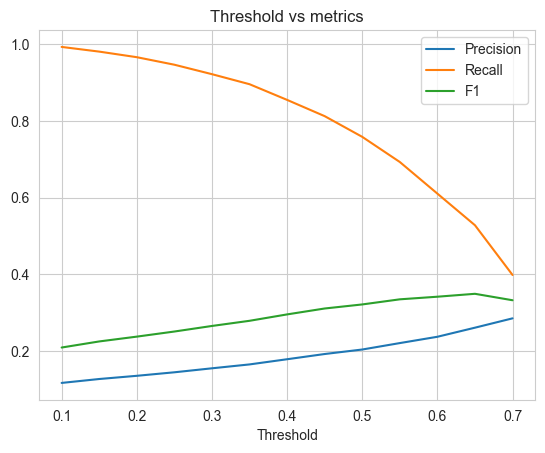

Chosen threshold: 0.1


In [48]:
plt.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision")
plt.plot(thresh_df["threshold"], thresh_df["recall"], label="Recall")
plt.plot(thresh_df["threshold"], thresh_df["f1"], label="F1")
plt.xlabel("Threshold"); plt.legend(); plt.title("Threshold vs metrics")
plt.show()

CHOSEN_THRESHOLD = 0.10 
print("Chosen threshold:", CHOSEN_THRESHOLD)

## probability calibration

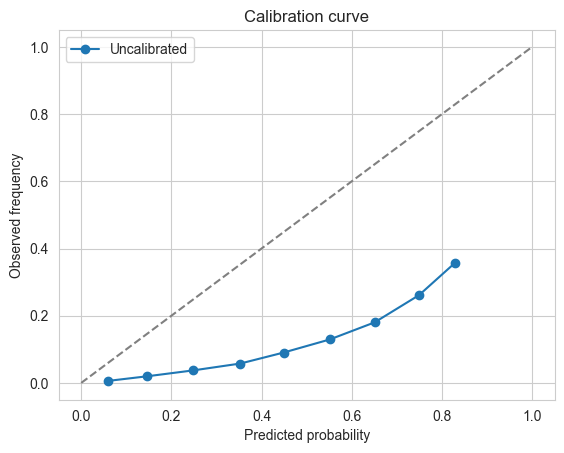

Brier score (uncalibrated): 0.19804956018924713


In [49]:
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
plt.plot(prob_pred, prob_true, marker="o", label="Uncalibrated")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.legend(); plt.title("Calibration curve")
plt.show()
print("Brier score (uncalibrated):", brier_score_loss(y_test, proba_test))

Brier score (calibrated): 0.0835181705766741


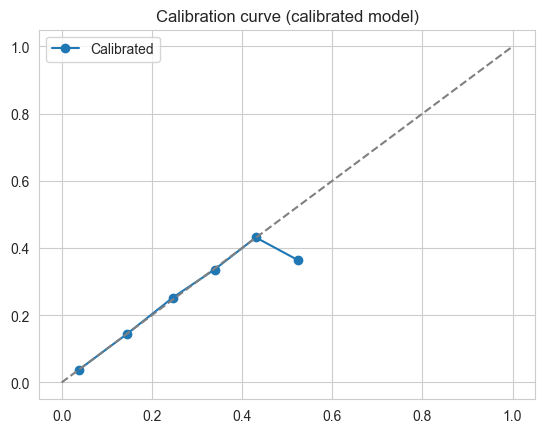

In [50]:
calibrated_model = CalibratedClassifierCV(best_model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)
proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
print("Brier score (calibrated):", brier_score_loss(y_test, proba_cal))

prob_true_c, prob_pred_c = calibration_curve(y_test, proba_cal, n_bins=10)
plt.plot(prob_pred_c, prob_true_c, marker="o", label="Calibrated")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.legend(); plt.title("Calibration curve (calibrated model)")
plt.show()

In [51]:
thresholds = np.arange(0.05, 0.55, 0.05)
rows = []
for t in thresholds:
    pred_t = (proba_cal >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, pred_t),
        "recall": recall_score(y_test, pred_t),
        "f1": f1_score(y_test, pred_t),
    })
thresh_df_cal = pd.DataFrame(rows)
thresh_df_cal

,threshold,precision,recall,f1
0,0.05,0.158819,0.911659,0.270512
1,0.10,0.198611,0.784103,0.316942
2,0.15,0.234394,0.623023,0.340634
3,0.20,0.278371,0.439595,0.340881
4,0.25,0.313162,0.305503,0.309285
5,0.30,0.346929,0.148851,0.208321
6,0.35,0.369399,0.071263,0.119477
7,0.40,0.428571,0.021505,0.040956
8,0.45,0.423077,0.002319,0.004613
9,0.50,0.363636,0.000843,0.001683


## final evaluation

Accuracy: 0.6511956829209914
Precision: 0.19861148197596795
Recall: 0.7841028884672149
F1: 0.31694221919209137
ROC-AUC: 0.7770085505580315
PR-AUC: 0.2641462148419208

TN=26208  FP=15006  FN=1024  TP=3719


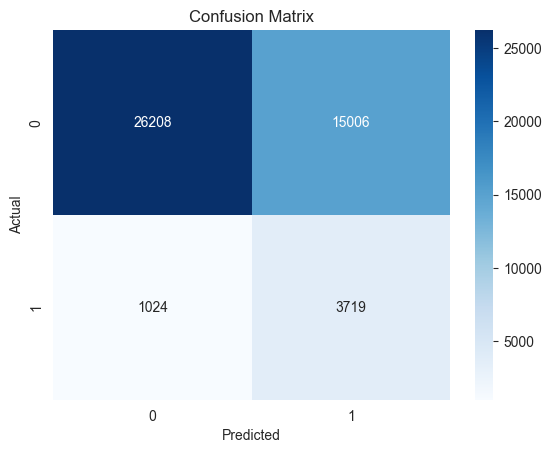

In [52]:
final_pred = (proba_cal >= CHOSEN_THRESHOLD).astype(int)

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))
print("ROC-AUC:", roc_auc_score(y_test, proba_cal))
print("PR-AUC:", average_precision_score(y_test, proba_cal))

cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

## Model Explainability

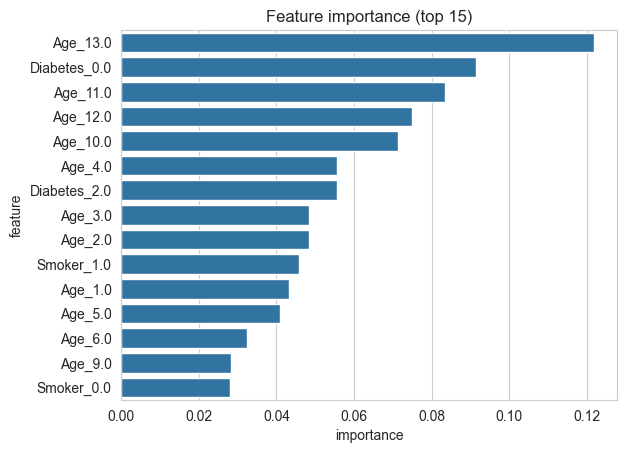

In [53]:
ohe = best_model.named_steps["prep"].named_transformers_["cat"]
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
importances = best_model.named_steps["clf"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False).head(15)
sns.barplot(x="importance", y="feature", data=imp_df)
plt.title("Feature importance (top 15)")
plt.show()

In [54]:
perm = permutation_importance(best_model, X_test, y_test, scoring="average_precision",
                               n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({"feature": X_test.columns, "importance": perm.importances_mean}
                        ).sort_values("importance", ascending=False)
perm_df

,feature,importance
0,Age,0.105084
8,Diabetes,0.033353
1,Sex,0.030059
3,Smoker,0.015848
5,PhysActivity,0.005325
2,BMI,0.003843
4,HvyAlcoholConsump,0.002377
7,Veggies,0.000145
6,Fruits,-0.000015


In [55]:
pip install shap   

Note: you may need to restart the kernel to use updated packages.


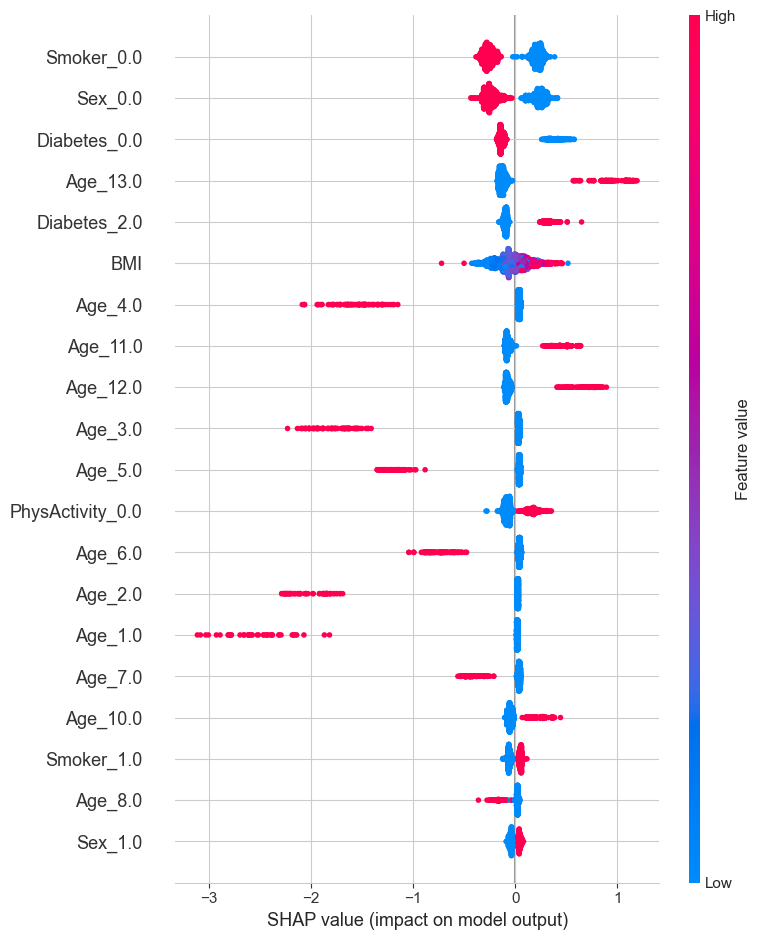

In [56]:
import shap

X_test_transformed = best_model.named_steps["prep"].transform(X_test.sample(2000, random_state=RANDOM_STATE))
explainer = shap.TreeExplainer(best_model.named_steps["clf"])
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

In [57]:
## local explaination for a single user
i = 0
sample_row = X_test.iloc[[i]]
sample_transformed = best_model.named_steps["prep"].transform(sample_row)
sample_shap = explainer.shap_values(sample_transformed)

local_df = pd.DataFrame({"feature": feature_names, "shap_value": sample_shap[0]}
                         ).sort_values("shap_value", key=abs, ascending=False).head(8)
local_df

,feature,shap_value
7,Age_7.0,-0.497234
16,Smoker_0.0,0.252006
14,Sex_0.0,0.248067
26,Diabetes_0.0,-0.140373
13,Age_13.0,-0.123103
28,Diabetes_2.0,-0.104749
12,Age_12.0,-0.083585
11,Age_11.0,-0.081673


## robustness checks

In [58]:
seed_scores = []
for seed in [0, 1, 42, 123, 2024]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    m = Pipeline([("prep", preprocessor), ("clf", best_model.named_steps["clf"])])
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    seed_scores.append({"seed": seed, "roc_auc": roc_auc_score(yte, p),
                         "pr_auc": average_precision_score(yte, p)})
pd.DataFrame(seed_scores)

,seed,roc_auc,pr_auc
0,0,0.774734,0.266140
1,1,0.774642,0.258901
2,42,0.777183,0.264158
3,123,0.771782,0.259517
4,2024,0.776913,0.267092


In [59]:
def subgroup_report(group_col):
    rows = []
    for val, idx in X_test.groupby(group_col).groups.items():
        yt = y_test.loc[idx]
        if yt.sum() == 0:
            continue
        p = proba_cal[X_test.index.get_indexer(idx)]
        rows.append({group_col: val, "n": len(idx), "positive_rate": yt.mean(),
                      "roc_auc": roc_auc_score(yt, p), "pr_auc": average_precision_score(yt, p)})
    return pd.DataFrame(rows)

subgroup_report("Age")

,Age,n,positive_rate,roc_auc,pr_auc
0,1.0,1109,0.005410,0.440692,0.005042
1,2.0,1394,0.003587,0.767603,0.023300
2,3.0,1966,0.013225,0.607603,0.022182
3,4.0,2461,0.012597,0.691371,0.033419
4,5.0,2824,0.025850,0.732434,0.075146
5,6.0,3454,0.035321,0.702892,0.084411
6,7.0,4635,0.061704,0.690731,0.129133
7,8.0,5552,0.083033,0.680374,0.165965
8,9.0,5942,0.113430,0.695542,0.226528
9,10.0,5828,0.143960,0.701603,0.263395


In [60]:
subgroup_report("Sex")

,Sex,n,positive_rate,roc_auc,pr_auc
0,0.0,25718,0.079283,0.763034,0.202215
1,1.0,20239,0.133603,0.769127,0.299634


# save model, preprocessor, metadata

In [62]:
import os
import json
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(calibrated_model, "models/lifestyle_model.pkl")
joblib.dump(preprocessor, "models/lifestyle_preprocessor.pkl")

lifestyle_metadata = {
    "model_version": "v2.0",
    "stage": "lifestyle_screening",
    "random_state": RANDOM_STATE,
    "features": lifestyle_cols,
    "target": target,
    "threshold": float(CHOSEN_THRESHOLD),
    "test_metrics": {
        "accuracy": float(accuracy_score(y_test, final_pred)),
        "precision": float(precision_score(y_test, final_pred)),
        "recall": float(recall_score(y_test, final_pred)),
        "f1": float(f1_score(y_test, final_pred)),
        "roc_auc": float(roc_auc_score(y_test, proba_cal)),
        "pr_auc": float(average_precision_score(y_test, proba_cal)),
        "brier_score": float(brier_score_loss(y_test, proba_cal)),
    },
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
}

with open("models/lifestyle_metadata.json", "w") as f:
    json.dump(lifestyle_metadata, f, indent=2)

print("Saved lifestyle model artifacts successfully.")
lifestyle_metadata

Saved lifestyle model artifacts successfully.


{'model_version': 'v2.0',
 'stage': 'lifestyle_screening',
 'random_state': 42,
 'features': ['Age',
  'Sex',
  'BMI',
  'Smoker',
  'HvyAlcoholConsump',
  'PhysActivity',
  'Fruits',
  'Veggies',
  'Diabetes'],
 'target': 'HeartDiseaseorAttack',
 'threshold': 0.1,
 'test_metrics': {'accuracy': 0.6511956829209914,
  'precision': 0.19861148197596795,
  'recall': 0.7841028884672149,
  'f1': 0.31694221919209137,
  'roc_auc': 0.7770085505580315,
  'pr_auc': 0.2641462148419208,
  'brier_score': 0.0835181705766741},
 'training_rows': 183824,
 'test_rows': 45957}